# Guide I: Predicting Outcomes – Image Analysis Practicum

This notebook will walk you through the practical steps of loading, preprocessing, analyzing, modeling, and evaluating image data for outcome prediction.

## 1. Import Required Libraries

In [16]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mihsanpermana/vanilla-plant-disease-image-dataset")

print("Path to dataset files:", path)

100%|██████████| 4.06G/4.06G [02:26<00:00, 29.8MB/s]

Extracting files...


Path to dataset files: /Users/anastasiiakulakova/.cache/kagglehub/datasets/mihsanpermana/vanilla-plant-disease-image-dataset/versions/1


## 2. Explore the PDT Dataset

Let's inspect a few samples from the PDT dataset to understand its structure and contents.

Dataset Classes and Samples:

Total classes: 4
--------------------------------------------------
Healthy: 500 samples
black spots: 500 samples
red spots: 500 samples
rotten stem: 500 samples


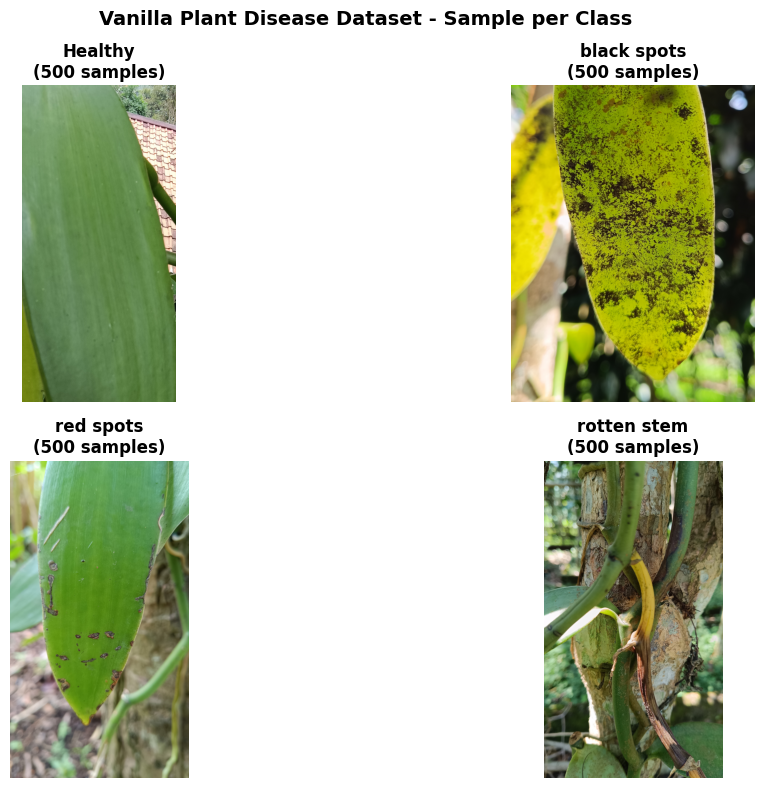


✓ Displayed one sample image per class


In [20]:
import os
from collections import defaultdict
from PIL import Image
import matplotlib.pyplot as plt

# Get all image files and organize by class (folder structure)
class_samples = defaultdict(list)

for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            class_name = os.path.basename(root)
            file_path = os.path.join(root, file)
            class_samples[class_name].append(file_path)

# Display class information
print(f"Dataset Classes and Samples:\n")
print(f"Total classes: {len(class_samples)}")
print("-" * 50)

for class_name in sorted(class_samples.keys()):
    num_samples = len(class_samples[class_name])
    print(f"{class_name}: {num_samples} samples")

# Display one sample image per class
num_classes = len(class_samples)
fig, axes = plt.subplots(2, (num_classes + 1) // 2, figsize=(14, 8))
axes = axes.flatten()

for idx, (class_name, file_paths) in enumerate(sorted(class_samples.items())):
    if file_paths:
        img = Image.open(file_paths[0])
        axes[idx].imshow(img)
        axes[idx].set_title(f"{class_name}\n({len(file_paths)} samples)", fontweight='bold')
        axes[idx].axis('off')

# Hide extra subplots
for idx in range(num_classes, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Vanilla Plant Disease Dataset - Sample per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n✓ Displayed one sample image per class")

In [23]:
class_samples['black spots']

['/Users/anastasiiakulakova/.cache/kagglehub/datasets/mihsanpermana/vanilla-plant-disease-image-dataset/versions/1/vanilla dataset/black spots/IMG_20250527_124951.jpg',
 '/Users/anastasiiakulakova/.cache/kagglehub/datasets/mihsanpermana/vanilla-plant-disease-image-dataset/versions/1/vanilla dataset/black spots/IMG_20250527_131435.jpg',
 '/Users/anastasiiakulakova/.cache/kagglehub/datasets/mihsanpermana/vanilla-plant-disease-image-dataset/versions/1/vanilla dataset/black spots/IMG_20250524_100341.jpg',
 '/Users/anastasiiakulakova/.cache/kagglehub/datasets/mihsanpermana/vanilla-plant-disease-image-dataset/versions/1/vanilla dataset/black spots/IMG_20250531_103435.jpg',
 '/Users/anastasiiakulakova/.cache/kagglehub/datasets/mihsanpermana/vanilla-plant-disease-image-dataset/versions/1/vanilla dataset/black spots/IMG_20250524_094911.jpg',
 '/Users/anastasiiakulakova/.cache/kagglehub/datasets/mihsanpermana/vanilla-plant-disease-image-dataset/versions/1/vanilla dataset/black spots/IMG_20250527

## 3. Preprocess Images

Now let's preprocess the images for modeling with resizing and normalization using torchvision.


In [27]:
import torch
from torchvision import transforms
import numpy as np

# Define preprocessing pipeline
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..2.64].


Image path: /Users/anastasiiakulakova/.cache/kagglehub/datasets/mihsanpermana/vanilla-plant-disease-image-dataset/versions/1/vanilla dataset/black spots/IMG_20250527_124951.jpg
Original image size: (1947, 2536)
Preprocessed tensor shape: torch.Size([3, 224, 224])
Preprocessed tensor dtype: torch.float32
Tensor value range: [-1.981, 2.640]


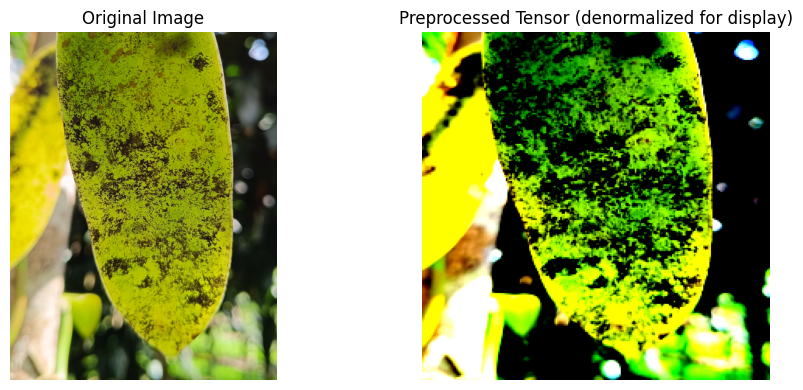

In [28]:
# Load and preprocess first image from black spots folder
black_spots_img_path = class_samples['black spots'][0]
img = Image.open(black_spots_img_path)

# Apply preprocessing
img_tensor = preprocess(img)

print(f"Image path: {black_spots_img_path}")
print(f"Original image size: {img.size}")
print(f"Preprocessed tensor shape: {img_tensor.shape}")
print(f"Preprocessed tensor dtype: {img_tensor.dtype}")
print(f"Tensor value range: [{img_tensor.min():.3f}, {img_tensor.max():.3f}]")

# Display original and preprocessed
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(img_tensor.permute(1, 2, 0).numpy())
axes[1].set_title("Preprocessed Tensor (denormalized for display)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 4. Build and Prepare Model

Define a simple CNN model and prepare for training.


In [30]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    """Simple CNN for image classification"""
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        
        # Calculate flattened size: 224 -> 112 -> 56 -> 28
        self.fc1 = nn.Linear(128 * 28 * 28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x


In [31]:
# Create dataset from class_samples dictionary
dataset_list = []
class_to_label = {}
label_counter = 0

for class_name in sorted(class_samples.keys()):
    class_to_label[class_name] = label_counter
    for file_path in class_samples[class_name]:
        dataset_list.append({
            'image': file_path,
            'label': label_counter
        })
    label_counter += 1

num_classes = len(class_samples)

print(f"Number of unique classes: {num_classes}")
print(f"Classes: {sorted(class_samples.keys())}")
print(f"Total samples: {len(dataset_list)}")

# Create model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN(num_classes).to(device)

print(f"\nModel created and moved to {device}")
print(f"Model architecture:")
print(model)

Number of unique classes: 4
Classes: ['Healthy', 'black spots', 'red spots', 'rotten stem']
Total samples: 2000

Model created and moved to cpu
Model architecture:
SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=100352, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=4, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [39]:
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.model_selection import train_test_split

import torch.optim as optim

# Custom Dataset class
class VanillaDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        item = self.data_list[idx]
        img = Image.open(item['image']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, item['label']

# Split dataset into train (80%) and test (20%)
train_list, test_list = train_test_split(dataset_list, test_size=0.2, random_state=42,
                                          stratify=[d['label'] for d in dataset_list])

train_dataset = VanillaDataset(train_list, transform=preprocess)
test_dataset = VanillaDataset(test_list, transform=preprocess)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

In [40]:
print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

Train samples: 1600, Test samples: 400


In [41]:
# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 10
train_losses, test_accuracies = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Evaluate on test set
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total * 100
    test_accuracies.append(accuracy)
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f} | Test Accuracy: {accuracy:.2f}%")

Epoch [1/10] Loss: 1.1432 | Test Accuracy: 64.75%
Epoch [2/10] Loss: 0.7985 | Test Accuracy: 78.00%
Epoch [3/10] Loss: 0.6845 | Test Accuracy: 75.00%
Epoch [4/10] Loss: 0.6246 | Test Accuracy: 75.25%
Epoch [5/10] Loss: 0.5384 | Test Accuracy: 77.00%
Epoch [6/10] Loss: 0.4358 | Test Accuracy: 82.00%
Epoch [7/10] Loss: 0.3690 | Test Accuracy: 80.50%
Epoch [8/10] Loss: 0.3560 | Test Accuracy: 76.25%
Epoch [9/10] Loss: 0.3402 | Test Accuracy: 79.00%
Epoch [10/10] Loss: 0.2501 | Test Accuracy: 83.50%


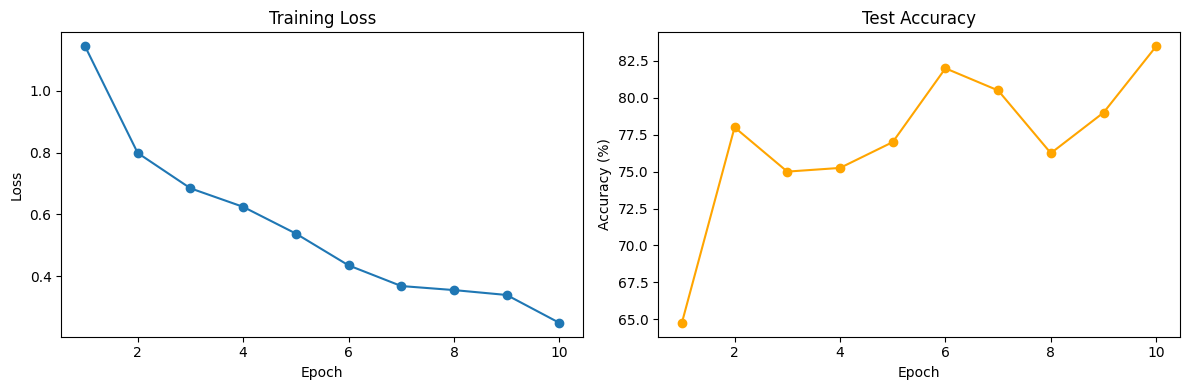

In [42]:
# Plot training progress
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(range(1, num_epochs+1), train_losses, marker='o')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.plot(range(1, num_epochs+1), test_accuracies, marker='o', color='orange')
ax2.set_title('Test Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')

plt.tight_layout()
plt.show()

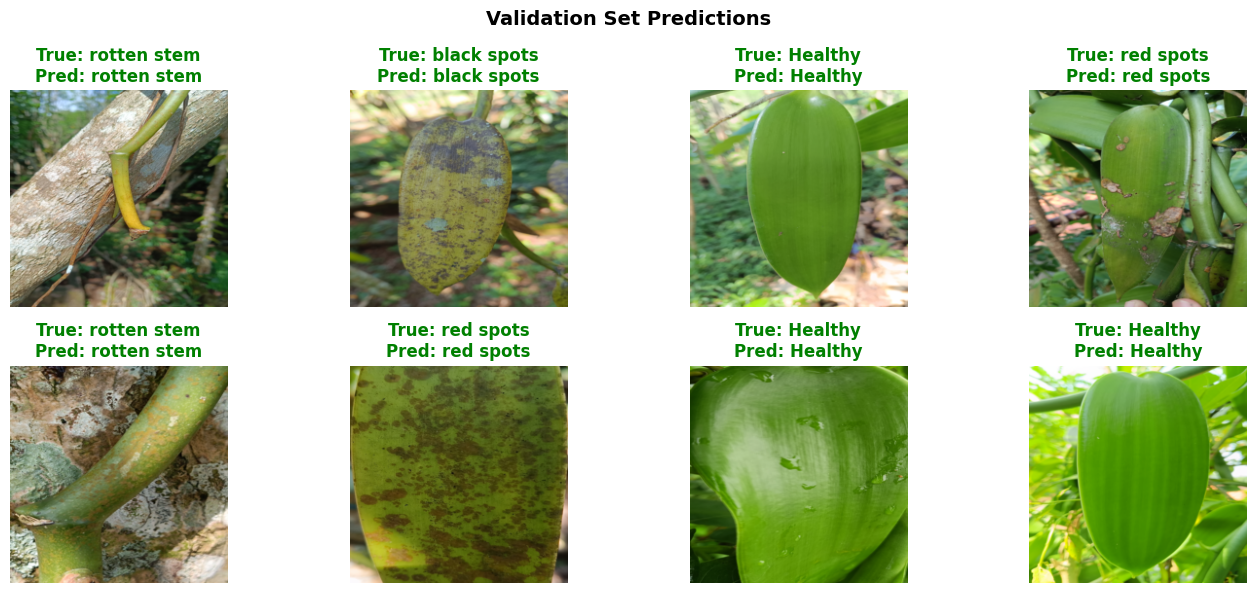

In [43]:
# Get a batch of validation images
val_images, val_labels = next(iter(test_loader))

# Move to device and get predictions
val_images = val_images.to(device)
model.eval()
with torch.no_grad():
    val_outputs = model(val_images)
    _, val_predicted = torch.max(val_outputs, 1)

# Map labels back to class names
label_to_class = {v: k for k, v in class_to_label.items()}

# Plot results
num_samples = 8
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()

for idx in range(num_samples):
    # Denormalize for display
    img = val_images[idx].cpu().permute(1, 2, 0).numpy()
    img = (img * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    
    axes[idx].imshow(img)
    true_label = label_to_class[val_labels[idx].item()]
    pred_label = label_to_class[val_predicted[idx].item()]
    color = 'green' if true_label == pred_label else 'red'
    axes[idx].set_title(f'True: {true_label}\nPred: {pred_label}', color=color, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Validation Set Predictions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [48]:
len(val_predicted_np)

32

Test Accuracy: 0.8350

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.94      0.84      0.89       100
 black spots       0.78      0.72      0.75       100
   red spots       0.70      0.81      0.75       100
 rotten stem       0.94      0.97      0.96       100

    accuracy                           0.83       400
   macro avg       0.84      0.83      0.84       400
weighted avg       0.84      0.83      0.84       400


Confusion Matrix:
[[84  4 12  0]
 [ 2 72 21  5]
 [ 3 15 81  1]
 [ 0  1  2 97]]


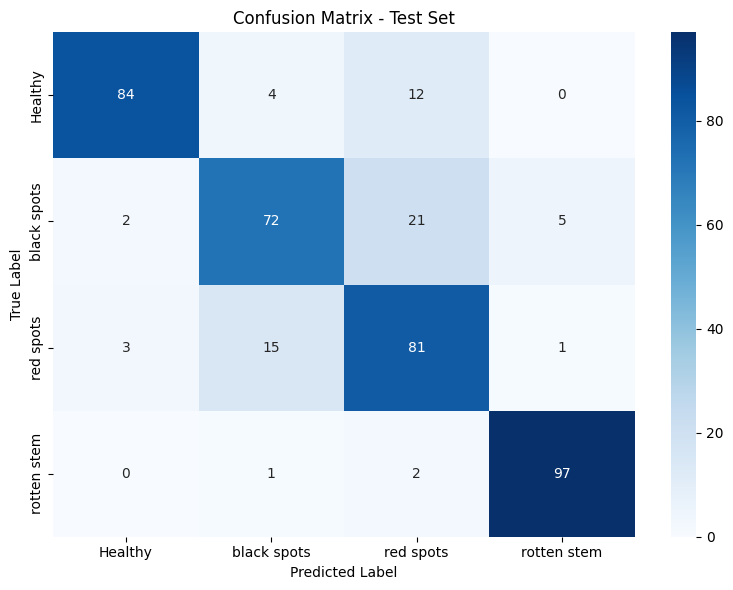

In [50]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns

# Get predictions for the entire test set
all_labels = []
all_predictions = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

all_labels_np = np.array(all_labels)
all_predictions_np = np.array(all_predictions)

# Calculate metrics
accuracy = accuracy_score(all_labels_np, all_predictions_np)
conf_matrix = confusion_matrix(all_labels_np, all_predictions_np)
class_report = classification_report(all_labels_np, all_predictions_np, 
                                     target_names=sorted(label_to_class.values()))

print(f"Test Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(class_report)
print("\nConfusion Matrix:")
print(conf_matrix)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(label_to_class.values()),
            yticklabels=sorted(label_to_class.values()))
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()